<a href="https://colab.research.google.com/github/alisony755/DS4400/blob/main/HW3/DS3000_HW3_Problem3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem 3

In [6]:
# Import numpy, pandas, and sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

In [7]:
# Import model evaluation tools
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

In [8]:
!pip install -U ucimlrepo

from ucimlrepo import fetch_ucirepo

# Detch dataset
spambase = fetch_ucirepo(id=94)

# Data (as pandas dataframes)
X = spambase.data.features
y = spambase.data.targets

# Print metadata
print(spambase.metadata)

# Print variable information
print(spambase.variables)

{'uci_id': 94, 'name': 'Spambase', 'repository_url': 'https://archive.ics.uci.edu/dataset/94/spambase', 'data_url': 'https://archive.ics.uci.edu/static/public/94/data.csv', 'abstract': 'Classifying Email as Spam or Non-Spam', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 4601, 'num_features': 57, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1999, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C53G6X', 'creators': ['Mark Hopkins', 'Erik Reeber', 'George Forman', 'Jaap Suermondt'], 'intro_paper': None, 'additional_info': {'summary': 'The "spam" concept is diverse: advertisements for products/web sites, make money fast schemes, chain letters, pornography...\n\nThe classification task for this dataset is to determine whether a given email is spam or not.\n\t\nOur collecti

In [9]:
def print_metrics(y_true, y_pred, dataset_name="spambase"):
    """
    Computes and prints classification metrics.

    Args:
        y_true (array-like): True labels
        y_pred (array-like): Predicted labels
        dataset_name (str): Name of dataset for display
    """

    # Compute accuracy
    acc = accuracy_score(y_true, y_pred)

    # Compute error rate
    error = 1 - acc

    # Compute precision
    prec = precision_score(y_true, y_pred)

    # Compute recall
    rec = recall_score(y_true, y_pred)

    # Print results
    print(f"\n{dataset_name} Metrics:")
    print("Accuracy:", acc)
    print("Error:", error)
    print("Precision:", prec)
    print("Recall:", rec)

In [10]:
# Convert pandas DataFrames to numpy arrays
X = X.values

# Convert target to 1D array
y = y.values.ravel()

# Split dataset into training (75%) and testing (25%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,      # 25% test, 75% train
    random_state=42      # Ensures reproducibility
)

# Scale features (important for logistic regression and kNN)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit scaler ONLY on training data, then transform both
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
# Create logistic regression model
log_reg = LogisticRegression(max_iter=5000)

# Train model on training data
log_reg.fit(X_train, y_train)

# Predict on training and testing data
y_train_pred_lr = log_reg.predict(X_train)
y_test_pred_lr = log_reg.predict(X_test)

# Print metrics
print_metrics(y_train, y_train_pred_lr, "Logistic Regression - Training")
print_metrics(y_test, y_test_pred_lr, "Logistic Regression - Testing")


Logistic Regression - Training Metrics:
Accuracy: 0.9257971014492754
Error: 0.0742028985507246
Precision: 0.9239811912225705
Recall: 0.8811659192825112

Logistic Regression - Testing Metrics:
Accuracy: 0.9226759339704604
Error: 0.07732406602953956
Precision: 0.9406392694063926
Recall: 0.8673684210526316


In [12]:
# Create LDA model
lda = LinearDiscriminantAnalysis()

# Train model
lda.fit(X_train, y_train)

# Predictions
y_train_pred_lda = lda.predict(X_train)
y_test_pred_lda = lda.predict(X_test)

# Metrics
print_metrics(y_train, y_train_pred_lda, "LDA - Training")
print_metrics(y_test, y_test_pred_lda, "LDA - Testing")


LDA - Training Metrics:
Accuracy: 0.8866666666666667
Error: 0.11333333333333329
Precision: 0.9157155399473222
Recall: 0.7795216741405082

LDA - Testing Metrics:
Accuracy: 0.8853171155516942
Error: 0.11468288444830577
Precision: 0.9298245614035088
Recall: 0.7810526315789473


In [13]:
# Range of k values to test
k_values = range(1, 21)

# Store cross-validation errors
cv_errors = []

# Use stratified 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for k in k_values:

    # Create kNN model
    knn = KNeighborsClassifier(n_neighbors=k)

    # Perform cross-validation using accuracy
    scores = cross_val_score(knn, X_train, y_train, cv=cv, scoring='accuracy')

    # Compute average error
    avg_error = 1 - scores.mean()

    cv_errors.append(avg_error)

# Select best k (minimum error)
best_k = k_values[np.argmin(cv_errors)]

print("Best k:", best_k)

Best k: 7


In [14]:
# Train kNN with optimal k
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)

# Predictions
y_train_pred_knn = knn_best.predict(X_train)
y_test_pred_knn = knn_best.predict(X_test)

# Metrics
print_metrics(y_train, y_train_pred_knn, "kNN - Training")
print_metrics(y_test, y_test_pred_knn, "kNN - Testing")


kNN - Training Metrics:
Accuracy: 0.922608695652174
Error: 0.07739130434782604
Precision: 0.9167315175097276
Recall: 0.8804185351270553

kNN - Testing Metrics:
Accuracy: 0.9018245004344049
Error: 0.09817549956559513
Precision: 0.9113636363636364
Recall: 0.8442105263157895


AUC: 0.9747337278106509


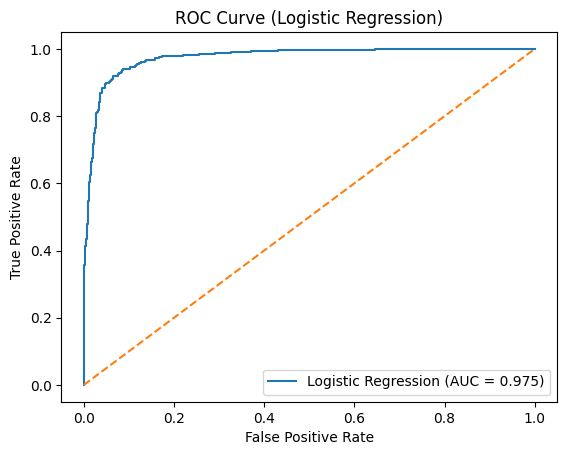

In [15]:
# ROC Curve + AUC using package

# Get predicted probabilities for positive class
y_test_probs_lr = log_reg.predict_proba(X_test)[:, 1]

# Compute ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_test_probs_lr)

# Compute AUC
auc_score = roc_auc_score(y_test, y_test_probs_lr)

print("AUC:", auc_score)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_score:.3f})")
plt.plot([0,1], [0,1], linestyle="--")  # Random classifier line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Logistic Regression)")
plt.legend()
plt.show()

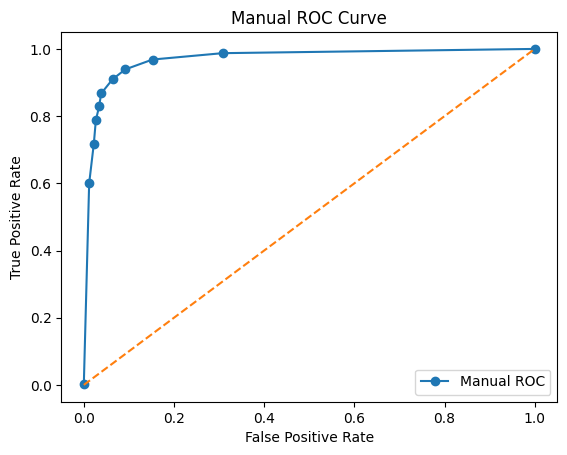

In [16]:
# Manual ROC Curve

# Get predicted probabilities
y_probs = log_reg.predict_proba(X_test)[:, 1]

# Threshold values
thresholds_manual = np.arange(0, 1.1, 0.1)

fpr_list = []
tpr_list = []

for T in thresholds_manual:

    # Convert probabilities to class predictions
    y_pred_thresh = (y_probs >= T).astype(int)

    # Compute confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thresh).ravel()

    # Compute false positive rate
    fpr = fp / (fp + tn)

    # Compute true positive rate
    tpr = tp / (tp + fn)

    fpr_list.append(fpr)
    tpr_list.append(tpr)

# Plot manual ROC
plt.figure()
plt.plot(fpr_list, tpr_list, marker='o', label="Manual ROC")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Manual ROC Curve")
plt.legend()
plt.show()